In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("C:\\Users\\Abhijeet ojha\\Downloads\\10) DateFruit Dataset.csv")

In [3]:
df.head()

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.908,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.144,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.394,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.210,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.354,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI


In [7]:
df['Class'].unique()

array(['BERHI', 'DEGLET', 'DOKOL', 'IRAQI', 'ROTANA', 'SAFAVI', 'SOGAY'],
      dtype=object)

In [5]:
X = df.drop('Class', axis=1)
y = df['Class']

In [10]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()
y = le.fit_transform(y)

In [11]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2, random_state=42
)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ANN

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [14]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)    

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)  

In [15]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [16]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [25]:
# building our model
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(X.shape[1],64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64, len(np.unique(y)))
        )
    def forward(self, x):
        return self.model(x)

In [26]:
model = ANN()
# loss & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [27]:
# training our nn

epochs = 100
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad() 

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    print(f'Epoch {epoch+1}/{epochs}, Loss: {train_loss}')

Epoch 1/100, Loss: 1.676571452099344
Epoch 2/100, Loss: 1.118447710638461
Epoch 3/100, Loss: 0.7473418686700903
Epoch 4/100, Loss: 0.5603944905426191
Epoch 5/100, Loss: 0.46547852132631384
Epoch 6/100, Loss: 0.4007842929466911
Epoch 7/100, Loss: 0.3575311108775761
Epoch 8/100, Loss: 0.3269089965716652
Epoch 9/100, Loss: 0.28957897489485535
Epoch 10/100, Loss: 0.269557976204416
Epoch 11/100, Loss: 0.25447231369174045
Epoch 12/100, Loss: 0.23728426092344782
Epoch 13/100, Loss: 0.22617432831422143
Epoch 14/100, Loss: 0.21373313956934473
Epoch 15/100, Loss: 0.20454051944872606
Epoch 16/100, Loss: 0.19821729381447253
Epoch 17/100, Loss: 0.19418716284891832
Epoch 18/100, Loss: 0.1838339991543604
Epoch 19/100, Loss: 0.17839706883482312
Epoch 20/100, Loss: 0.16984254121780396
Epoch 21/100, Loss: 0.1606405323938183
Epoch 22/100, Loss: 0.1699816424237645
Epoch 23/100, Loss: 0.155181882498057
Epoch 24/100, Loss: 0.1576909928218178
Epoch 25/100, Loss: 0.15500370380671127
Epoch 26/100, Loss: 0.1429

In [30]:
# evaluate
model.eval()
total = 0
correct = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Correct Predictions: {correct}, Total Predictions: {total}')
print(f'Accuracy: {100 * correct / total}%')


Correct Predictions: 167, Total Predictions: 180
Accuracy: 92.77777777777777%


# increasing accuracy using PCA

In [43]:
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensionality
n_components = 15  
pca = PCA(n_components=n_components)

# Fit PCA on training data and transform both train and test sets
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Convert to torch tensors
X_train_pca_tensor = torch.tensor(X_train_pca, dtype=torch.float32)
X_test_pca_tensor = torch.tensor(X_test_pca, dtype=torch.float32)

# Create new datasets and dataloaders with PCA-reduced data
train_dataset_pca = TensorDataset(X_train_pca_tensor, y_train_tensor)
test_dataset_pca = TensorDataset(X_test_pca_tensor, y_test_tensor)

train_loader_pca = DataLoader(train_dataset_pca, batch_size=32, shuffle=True)
test_loader_pca = DataLoader(test_dataset_pca, batch_size=32, shuffle=False)
# Search for the best PCA component count using a simple loop
component_values = range(2, X_train_scaled.shape[1] + 1, 2)

best_acc = 0.0
best_n = 2
best_pca = None
best_model = None
best_train_loader = None
best_test_loader = None
best_X_train_pca = None
best_X_test_pca = None

for n in component_values:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    X_train_pca_tensor = torch.tensor(X_train_pca, dtype=torch.float32)
    X_test_pca_tensor = torch.tensor(X_test_pca, dtype=torch.float32)

    train_dataset_pca = TensorDataset(X_train_pca_tensor, y_train_tensor)
    test_dataset_pca = TensorDataset(X_test_pca_tensor, y_test_tensor)

    train_loader_pca = DataLoader(train_dataset_pca, batch_size=32, shuffle=True)
    test_loader_pca = DataLoader(test_dataset_pca, batch_size=32, shuffle=False)

    model_pca = nn.Sequential(
        nn.Linear(X_train_pca.shape[1], 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, len(np.unique(y)))
    )

    criterion_pca = nn.CrossEntropyLoss()
    optimizer_pca = optim.Adam(model_pca.parameters(), lr=0.001)

    for _ in range(30):
        model_pca.train()
        for inputs, labels in train_loader_pca:
            optimizer_pca.zero_grad()
            outputs = model_pca(inputs)
            loss = criterion_pca(outputs, labels)
            loss.backward()
            optimizer_pca.step()

    model_pca.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        # change this line before the loop
        component_values = range(1, 31)

        # replace the selected block with:
        for inputs, labels in test_loader_pca:
            outputs = model_pca(inputs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
                    

    acc = correct / total
    print(f"PCA components={n}, Accuracy={acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_n = n
        best_pca = pca
        best_model = model_pca
        best_X_train_pca = X_train_pca
        best_X_test_pca = X_test_pca
        best_train_loader = train_loader_pca
        best_test_loader = test_loader_pca

# Keep the best PCA configuration for later cells
n_components = best_n
pca = best_pca
model_pca = best_model
X_train_pca = best_X_train_pca
X_test_pca = best_X_test_pca
train_loader_pca = best_train_loader
test_loader_pca = best_test_loader

print(f"Best PCA components: {best_n}")
print(f"Best PCA accuracy: {best_acc:.4f}")
print(f"Original features: {X_train_scaled.shape[1]}")
print(f"PCA components: {n_components}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

PCA components=2, Accuracy=0.8500
PCA components=4, Accuracy=0.9056
PCA components=6, Accuracy=0.9056
PCA components=8, Accuracy=0.9167
PCA components=10, Accuracy=0.9333
PCA components=12, Accuracy=0.9500
PCA components=14, Accuracy=0.9556
PCA components=16, Accuracy=0.9222
PCA components=18, Accuracy=0.9444
PCA components=20, Accuracy=0.9556
PCA components=22, Accuracy=0.9556
PCA components=24, Accuracy=0.9611
PCA components=26, Accuracy=0.9167
PCA components=28, Accuracy=0.9500
PCA components=30, Accuracy=0.9611
PCA components=32, Accuracy=0.9556
PCA components=34, Accuracy=0.9611
Best PCA components: 24
Best PCA accuracy: 0.9611
Original features: 34
PCA components: 24
Explained variance ratio: 0.9999


In [44]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=len(np.unique(y)), random_state=42)
labels = kmeans.fit_predict(X_train_scaled)

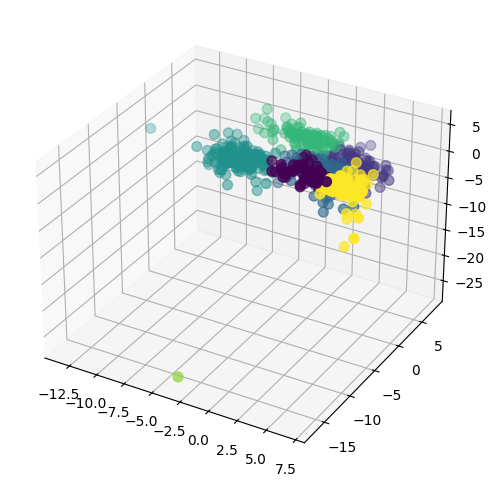

In [45]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
kmeans_pca = KMeans(n_clusters=len(np.unique(y)), random_state=42)
labels_pca = kmeans_pca.fit_predict(X_train_pca)

ax.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    X_train_pca[:, 2],
    c=labels_pca,
    cmap='viridis',
    s=50
)

In [46]:
# Train ANN using PCA-transformed features

# Use the best PCA component count found earlier
n_components = best_n
pca = PCA(n_components=n_components)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

X_train_pca_tensor = torch.tensor(X_train_pca, dtype=torch.float32)
X_test_pca_tensor = torch.tensor(X_test_pca, dtype=torch.float32)

train_dataset_pca = TensorDataset(X_train_pca_tensor, y_train_tensor)
test_dataset_pca = TensorDataset(X_test_pca_tensor, y_test_tensor)

train_loader_pca = DataLoader(train_dataset_pca, batch_size=32, shuffle=True)
test_loader_pca = DataLoader(test_dataset_pca, batch_size=32, shuffle=False)

model_pca = nn.Sequential(
    nn.Linear(X_train_pca.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, len(np.unique(y)))
)

model_pca = model_pca
criterion_pca = nn.CrossEntropyLoss()
optimizer_pca = optim.Adam(model_pca.parameters(), lr=0.001)

epochs = 100
for epoch in range(epochs):
    model_pca.train()
    running_loss = 0.0

    for inputs, labels in train_loader_pca:
        optimizer_pca.zero_grad()
        outputs = model_pca(inputs)
        loss = criterion_pca(outputs, labels)
        loss.backward()
        optimizer_pca.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader_pca)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {train_loss:.4f}")

model_pca.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader_pca:
        outputs = model_pca(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Correct Predictions: {correct}, Total Predictions: {total}")
print(f"PCA Model Accuracy: {100 * correct / total:.2f}%")

Epoch 1/100, Loss: 1.7243
Epoch 10/100, Loss: 0.2302
Epoch 20/100, Loss: 0.1289
Epoch 30/100, Loss: 0.0901
Epoch 40/100, Loss: 0.0639
Epoch 50/100, Loss: 0.0463
Epoch 60/100, Loss: 0.0360
Epoch 70/100, Loss: 0.0257
Epoch 80/100, Loss: 0.0205
Epoch 90/100, Loss: 0.0140
Epoch 100/100, Loss: 0.0100
Correct Predictions: 173, Total Predictions: 180
PCA Model Accuracy: 96.11%
